In [29]:
import pandas as pd
from scipy.stats import beta, gamma
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


In [30]:
# 1. Datos (DataFrame con columna de éxitos/fracasos: 1 o 0)
df = pd.read_csv("../data/datos_inmobiliarios_ready.csv")
df.head()

,price_amount,admin_fee,area_built_m2,bedrooms,bathrooms,parking_spaces,stratum,floor,age_bracket_code,latitude,...,locality_frec,neighborhood_grouped_frec,publisher_type_desarrollador,publisher_type_inmobiliaria,property_type_apartaestudio,property_type_casa,property_type_casa_campestre,property_type_finca,property_type_habitacion,meses_ofertado
0,8.800000e+08,736000.00,160.000,3.0,3.0,2,4.0,2,4.0,4.711642,...,0.275462,0.690441,0,0,0,1,0,0,0,43
1,6.500000e+08,271123.04,153.400,4.0,2.0,1,3.0,2,5.0,4.655459,...,0.060219,0.690441,0,0,0,1,0,0,0,43
2,6.250000e+08,643500.00,120.000,4.0,3.0,2,5.0,1,4.0,4.764007,...,0.310195,0.690441,0,0,0,1,0,0,0,42
3,4.700000e+08,560000.00,56.000,1.0,2.0,1,4.0,2,2.0,4.721554,...,0.310195,0.690441,0,0,0,0,0,0,0,41
4,1.170000e+09,869954.98,79.473,2.0,2.0,2,6.0,14,1.0,4.685839,...,0.310195,0.025536,0,1,0,0,0,0,0,41


# Beta - Binomial

Según el CNPV-2018 del DANE, el 61,53% de la población vive en casa y el 32,75% en apartamento.

Como el mercado de vivienda usada se abastece del stock existente, se toma esa proporción como media a priori de θ = P(la propiedad sea casa). Se fija entonces una Beta(α, β) con media α/(α+β) ≈ 0,62 y una varianza de 0.03, luego es una prior debilmente informativa con:

$\alpha_0 \approx 4.25$

$\beta_0 \approx 2.6$

https://www.dane.gov.co/files/censo2018/informacion-tecnica/cnpv-2018-comunicado-3ra-entrega.pdf

In [31]:
# 2. Creación de la Prior Beta(a, b)
a_prior, b_prior = 4.25, 2.6
prior = beta(a_prior, b_prior)

# 3. Datos observados desde la columna del DataFrame
k = df["property_type_casa"].sum()  # Número de éxitos
n = len(df["property_type_casa"])  # Total de ensayos

# Likelihood normalizada como función de densidad equivalente a Beta(k + 1, n - k + 1)
likelihood = beta(k + 1, n - k + 1)

# 4. Creación de la Posterior Beta(a + k, b + n - k)
a_post = a_prior + k
b_post = b_prior + (n - k)
posterior = beta(a_post, b_post)

# Ejemplo de uso: Media y Moda (Estimador MAP) de la posterior
print(f"Media posterior (Esperanza): {posterior.mean():.3f}")
print(f"Moda posterior (MAP): {(a_post - 1) / (a_post + b_post - 2):.3f}")

Media posterior (Esperanza): 0.370
Moda posterior (MAP): 0.370


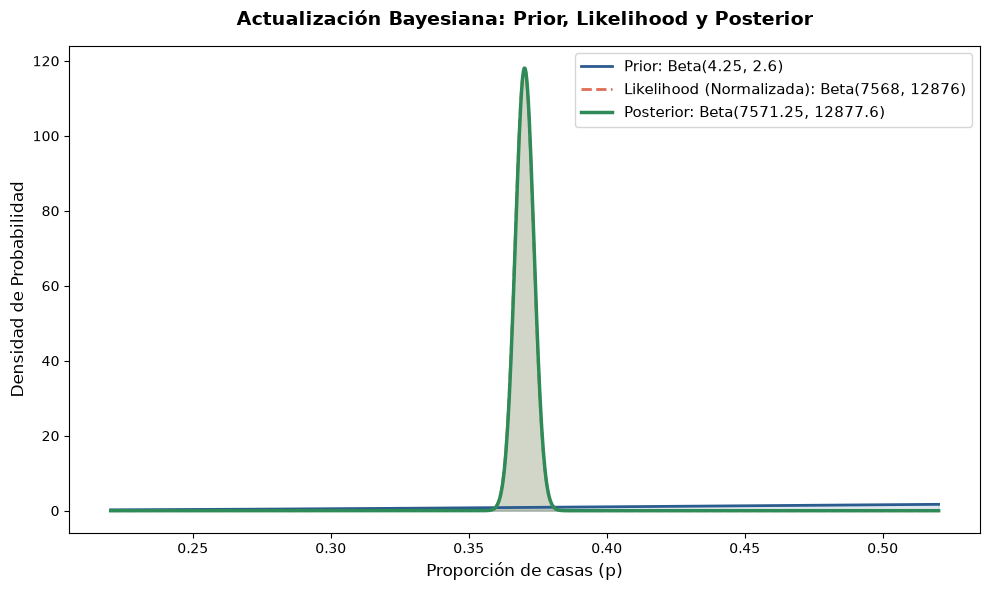

In [32]:
mu_post = a_post / (a_post + b_post)
x = np.linspace(max(0, mu_post - 0.15), min(1, mu_post + 0.15), 1000)

# Configuración de la figura
plt.figure(figsize=(10, 6))

# Trazado de las curvas con Seaborn
sns.lineplot(x=x, y=prior.pdf(x), label=f"Prior: Beta({a_prior}, {b_prior})", color="#2b5c8f", linewidth=2)
sns.lineplot(x=x, y=likelihood.pdf(x), label=f"Likelihood (Normalizada): Beta({k+1}, {n-k+1})", color="#e06d53", linewidth=2, linestyle="--")
sns.lineplot(x=x, y=posterior.pdf(x), label=f"Posterior: Beta({a_post}, {b_post})", color="#2e8b57", linewidth=2.5)

# Sombreado bajo las curvas
plt.fill_between(x, prior.pdf(x), alpha=0.15, color="#2b5c8f")
plt.fill_between(x, likelihood.pdf(x), alpha=0.15, color="#e06d53")
plt.fill_between(x, posterior.pdf(x), alpha=0.2, color="#2e8b57")

# Detalles del gráfico
plt.title("Actualización Bayesiana: Prior, Likelihood y Posterior", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Proporción de casas (p)", fontsize=12)
plt.ylabel("Densidad de Probabilidad", fontsize=12)
plt.legend(fontsize=11, loc="upper right")

plt.tight_layout()
plt.show()

# Multinomial dirichlet

Los cortes de $400 y $800 millones se definen a partir del umbral legal de Vivienda de Interés Social (135 SMMLV, y 150 SMMLV en aglomeraciones, Ley 388/1997 y Decreto 1467/2019), que con un SMMLV de $1.300.000 en 2024 equivale a $175,5–$195 millones. Así, el segmento "Económico" (≤ $400M ≈ 308 SMMLV) agrupa la VIS y la No VIS de entrada, "Normal" ($400–800M) corresponde a la No VIS de gama media y "Lujo" (> $800M ≈ 615 SMMLV) al extremo superior del mercado. Para las proporciones a priori se usa la composición de FIVI (DANE): en el tercer trimestre de 2024 se financiaron 47.571 viviendas, de las cuales 32.223 fueron VIS y 15.348 No VIS, es decir que el grueso de las transacciones se concentra en los rangos bajo y medio y la cola alta es marginal. Se fija entonces α = (α₁, α₂, α₃) con masa concentrada en las dos primeras categorías y α₃ pequeño.

https://www.dane.gov.co/files/operaciones/FIVI/bol-FIVI-IIItrim2024.pdf

In [33]:
df_diric = df.copy()
def clasificador_precios(col):
    if pd.isna(col):
        return np.nan
    if col <= 400_000_000:
        return "Economico"
    elif col <= 800_000_000:
        return "Normal"
    return "Lujo"

# crear categorias

df_diric["categorias"] = df_diric["price_amount"].apply(clasificador_precios)

# prior
alpha_prior = np.array([860, 3450, 690]) # 5000
a0_prior = np.sum(alpha_prior)

# observado

x = df_diric["categorias"].value_counts().reindex(["Economico", "Normal", "Lujo"], fill_value=0).to_numpy()
n = np.sum(x)
# posterior

alpha_post = alpha_prior + x
a0_post = np.sum(alpha_post)


In [34]:
x.sum()

np.int64(20442)

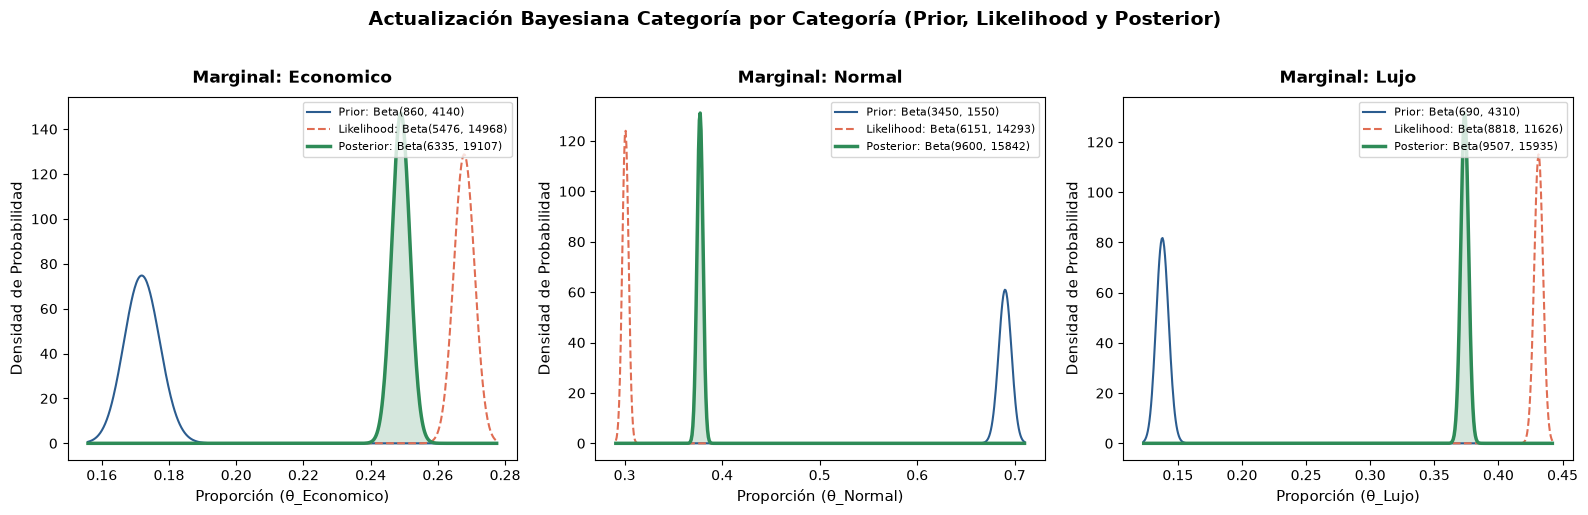

In [35]:
categorias = ["Economico", "Normal", "Lujo"]
# 2. Creación de la figura con 3 subplots (1 fila x 3 columnas)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, (cat, ax) in enumerate(zip(categorias, axes)):
    # Marginal Prior: Beta(alpha_i, a0_prior - alpha_i)
    a_pri = alpha_prior[i]
    b_pri = a0_prior - a_pri

    # Marginal Likelihood equivalente: Beta(k_i + 1, n - k_i + 1)
    k_i = x[i]
    a_lik = k_i + 1
    b_lik = n - k_i + 1

    # Marginal Posterior: Beta(alpha_post_i, a0_post - alpha_post_i)
    a_pos = alpha_post[i]
    b_pos = a0_post - a_pos

    pri_dist = beta(a_pri, b_pri)
    lik_dist = beta(a_lik, b_lik)
    pos_dist = beta(a_pos, b_pos)

    # Rango de x que cubre las tres distribuciones completas
    low = min(pri_dist.ppf(0.001), lik_dist.ppf(0.001), pos_dist.ppf(0.001))
    high = max(pri_dist.ppf(0.999), lik_dist.ppf(0.999), pos_dist.ppf(0.999))
    x_axis = np.linspace(max(0, low), min(1, high), 500)

    # Trazado de las curvas
    sns.lineplot(x=x_axis, y=pri_dist.pdf(x_axis), ax=ax, label=f"Prior: Beta({a_pri}, {b_pri:.0f})", color="#2b5c8f", lw=1.5)
    sns.lineplot(x=x_axis, y=lik_dist.pdf(x_axis), ax=ax, label=f"Likelihood: Beta({a_lik}, {b_lik})", color="#e06d53", linestyle="--", lw=1.5)
    sns.lineplot(x=x_axis, y=pos_dist.pdf(x_axis), ax=ax, label=f"Posterior: Beta({a_pos}, {b_pos:.0f})", color="#2e8b57", lw=2.5)

    # Sombreado bajo la posterior
    ax.fill_between(x_axis, pos_dist.pdf(x_axis), alpha=0.2, color="#2e8b57")

    # Formato
    ax.set_title(f"Marginal: {cat}", fontsize=12, fontweight="bold", pad=10)
    ax.set_xlabel(f"Proporción (θ_{cat})", fontsize=11)
    ax.set_ylabel("Densidad de Probabilidad", fontsize=11)
    ax.legend(fontsize=8, loc="upper right")

plt.suptitle("Actualización Bayesiana Categoría por Categoría (Prior, Likelihood y Posterior)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()